# Predicting Food Delivery Time using Machine Learning

**Course:** Machine Learning and AI  
**Project:** Predicting Delivery Times for Food Delivery Apps  
**Student:** Amal Fatima Jawed

---

## Problem Statement

Food delivery apps need to estimate how long an order will take to arrive to the customer. 
If the estimated delivery time is very wrong, customers get frustrated and may stop using the app.

In this project, I build a machine learning model that predicts the delivery time (in minutes) 
based on information about the order, the restaurant, and external conditions (like traffic or time of day).

## Machine Learning Objective

This is a **supervised regression** problem.

- **Input (features):** information about the food order (distance, time of day, traffic, etc.)
- **Output (target):** delivery time in minutes (a continuous numeric value)

The goal is to train a model that can accurately predict the delivery time for new orders.


### 1) Setup and Load the Dataset

In [309]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Set plot style
plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

In [310]:
# Load the dataset
df = pd.read_csv("Food_Delivery_Times_Expanded.csv")

# Show first 5 rows
df.head()


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12.0,1.0,43.0
1,738,16.42,Clear,Medium,Evening,Bike,20.0,2.0,84.0
2,741,9.52,Foggy,Low,Night,Scooter,28.0,1.0,59.0
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5.0,1.0,37.0
4,412,19.03,Clear,Low,Morning,Bike,16.0,5.0,68.0


In [311]:
df.shape

(10000, 9)

In [312]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                10000 non-null  int64  
 1   Distance_km             10000 non-null  float64
 2   Weather                 8460 non-null   object 
 3   Traffic_Level           7751 non-null   object 
 4   Time_of_Day             8123 non-null   object 
 5   Vehicle_Type            10000 non-null  object 
 6   Preparation_Time_min    10000 non-null  float64
 7   Courier_Experience_yrs  9970 non-null   float64
 8   Delivery_Time_min       10000 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 703.3+ KB


### 2) Data Cleaning and Preprocessing

In [313]:
#Unesscary column
df = df.drop(columns=["Order_ID"])


In [314]:
df.isna().sum()

Distance_km                  0
Weather                   1540
Traffic_Level             2249
Time_of_Day               1877
Vehicle_Type                 0
Preparation_Time_min         0
Courier_Experience_yrs      30
Delivery_Time_min            0
dtype: int64

In [315]:
# Fill missing categorical values
df["Weather"] = df["Weather"].fillna("Unknown")
df["Traffic_Level"] = df["Traffic_Level"].fillna("Unknown")
df["Time_of_Day"] = df["Time_of_Day"].fillna("Unknown")

# Fill missing numerical values
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(df["Courier_Experience_yrs"].median())


In [316]:
df.isna().sum()

Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [317]:
# Show first 5 rows
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12.0,1.0,43.0
1,16.42,Clear,Medium,Evening,Bike,20.0,2.0,84.0
2,9.52,Foggy,Low,Night,Scooter,28.0,1.0,59.0
3,7.44,Rainy,Medium,Afternoon,Scooter,5.0,1.0,37.0
4,19.03,Clear,Low,Morning,Bike,16.0,5.0,68.0


### 3) Exploratory Data Analysis

In [318]:
df.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,10000.000000,10000.00000,10000.000000,10000.000000
mean,12.389668,19.72570,4.986600,71.745000
std,6.947342,8.61462,3.122434,24.590288
min,0.500532,5.00000,0.000000,8.000000
25%,6.340571,12.00000,2.000000,53.000000
50%,12.371744,20.00000,5.000000,71.000000
75%,18.206168,27.00000,8.000000,89.000000
max,24.998763,35.00000,10.000000,153.000000


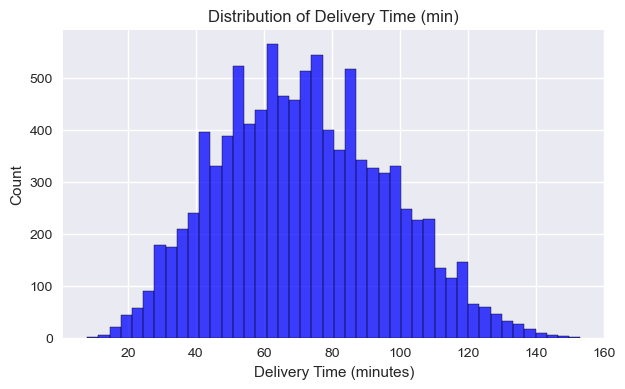

In [319]:
plt.figure(figsize=(7,4))
sns.histplot(df["Delivery_Time_min"], color="blue")
plt.title("Distribution of Delivery Time (min)")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Count")
plt.show()



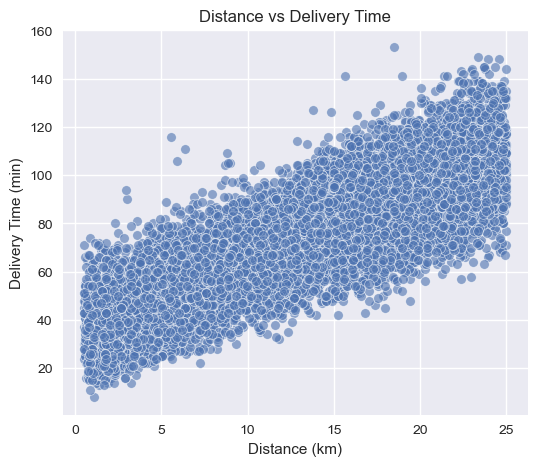

In [320]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Distance_km', y='Delivery_Time_min', alpha=0.6)
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()


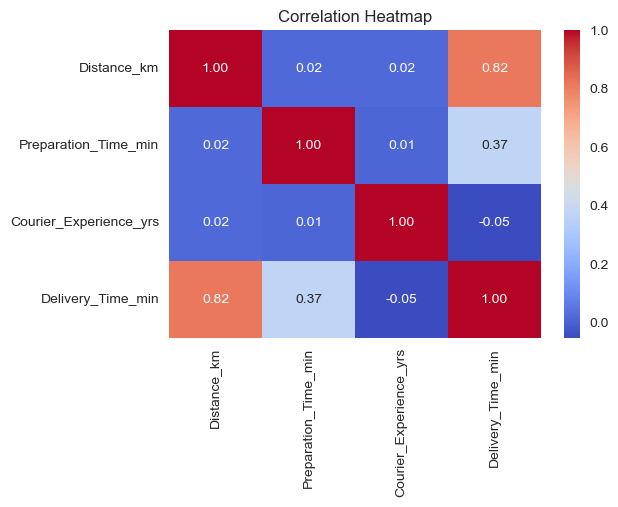

In [321]:
numeric_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']

plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


### 4) Feature Engineering

In [322]:
def map_peak(x):
    if x in ["Evening", "Afternoon"]:
        return 1
    return 0

df["Peak_Hour"] = df["Time_of_Day"].apply(map_peak)
df.head()


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Peak_Hour
0,7.93,Windy,Low,Afternoon,Scooter,12.0,1.0,43.0,1
1,16.42,Clear,Medium,Evening,Bike,20.0,2.0,84.0,1
2,9.52,Foggy,Low,Night,Scooter,28.0,1.0,59.0,0
3,7.44,Rainy,Medium,Afternoon,Scooter,5.0,1.0,37.0,1
4,19.03,Clear,Low,Morning,Bike,16.0,5.0,68.0,0


In [323]:
traffic_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Jam": 4,
    "Unknown": 2
}

df["Traffic_Intensity_Score"] = df["Traffic_Level"].map(traffic_map)
df.head()


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Peak_Hour,Traffic_Intensity_Score
0,7.93,Windy,Low,Afternoon,Scooter,12.0,1.0,43.0,1,1
1,16.42,Clear,Medium,Evening,Bike,20.0,2.0,84.0,1,2
2,9.52,Foggy,Low,Night,Scooter,28.0,1.0,59.0,0,1
3,7.44,Rainy,Medium,Afternoon,Scooter,5.0,1.0,37.0,1,2
4,19.03,Clear,Low,Morning,Bike,16.0,5.0,68.0,0,1


In [324]:
df["Distance_Traffic_Interaction"] = df["Distance_km"] * df["Traffic_Intensity_Score"]
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Peak_Hour,Traffic_Intensity_Score,Distance_Traffic_Interaction
0,7.93,Windy,Low,Afternoon,Scooter,12.0,1.0,43.0,1,1,7.93
1,16.42,Clear,Medium,Evening,Bike,20.0,2.0,84.0,1,2,32.84
2,9.52,Foggy,Low,Night,Scooter,28.0,1.0,59.0,0,1,9.52
3,7.44,Rainy,Medium,Afternoon,Scooter,5.0,1.0,37.0,1,2,14.88
4,19.03,Clear,Low,Morning,Bike,16.0,5.0,68.0,0,1,19.03


5) Train/Test Split

In [325]:
# Target variable
y = df["Delivery_Time_min"]

# Numeric features (including engineered ones)
numeric_features = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Peak_Hour",
    "Traffic_Intensity_Score",
    "Distance_Traffic_Interaction"
]

# Categorical features
categorical_features = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
]

# Combine into X
X = df[numeric_features + categorical_features]

X.shape, y.shape



((10000, 10), (10000,))

In [326]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((8000, 10), (2000, 10))

### Preprocessing Pipeline

In [327]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Scale numeric features
numeric_transformer = StandardScaler()

# One-hot encode categorical features
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


### 6) Model Training and Evaluation

In [328]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"MAE : {mae:.2f} minutes")
    print(f"RMSE: {rmse:.2f} minutes")
    print(f"R²  : {r2:.3f}")

    return mae, rmse, r2


In [329]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linear_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_lr = linear_model.predict(X_test)

metrics_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression")



=== Linear Regression ===
MAE : 5.24 minutes
RMSE: 7.19 minutes
R²  : 0.915


c:\Users\amald\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [330]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200, 
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

metrics_rf = evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")



=== Random Forest Regressor ===
MAE : 5.17 minutes
RMSE: 7.01 minutes
R²  : 0.919


c:\Users\amald\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [331]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

metrics_gbr = evaluate_model(y_test, y_pred_gbr, "Gradient Boosting Regressor")



=== Gradient Boosting Regressor ===
MAE : 4.62 minutes
RMSE: 6.44 minutes
R²  : 0.932


c:\Users\amald\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [332]:
results = pd.DataFrame([
    ["Linear Regression", *metrics_lr],
    ["Random Forest Regressor", *metrics_rf],
    ["Gradient Boosting Regressor", *metrics_gbr],
], columns=["Model", "MAE", "RMSE", "R²"])

results


,Model,MAE,RMSE,R²
0,Linear Regression,5.239670,7.188932,0.915073
1,Random Forest Regressor,5.174800,7.008263,0.919288
2,Gradient Boosting Regressor,4.620327,6.440690,0.931832


### 7) Feature Importance and Evaluation

In [333]:
# Access the preprocessor and model from the pipeline
rf_preprocessor = rf_model.named_steps["preprocess"]
rf_estimator = rf_model.named_steps["model"]

# Get numeric feature names directly
numeric_feature_names = numeric_features  # from your earlier code

# Get expanded categorical feature names after encoding
ohe = rf_preprocessor.named_transformers_["cat"]
categorical_feature_names = list(ohe.get_feature_names_out(categorical_features))

# Combine them
all_feature_names = numeric_feature_names + categorical_feature_names
len(all_feature_names)



24

In [334]:
importances = rf_estimator.feature_importances_

# Put into DataFrame
feat_importances = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)


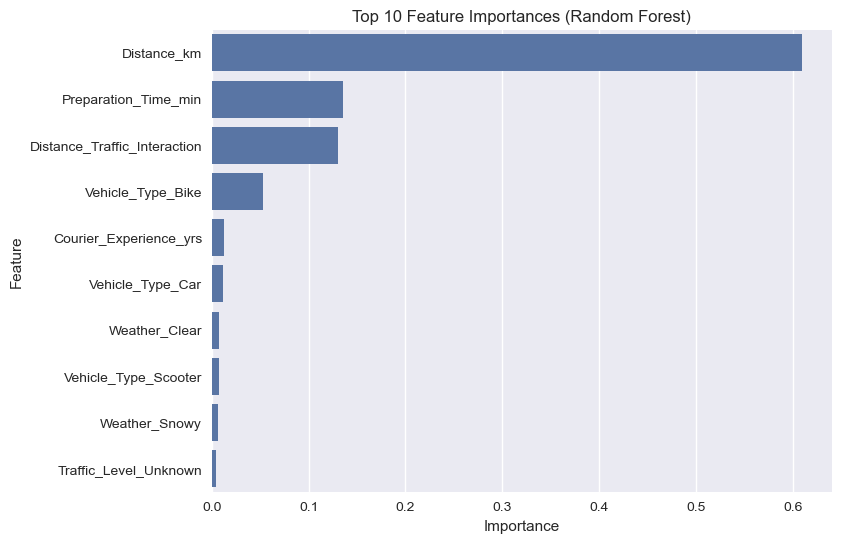

In [335]:
plt.figure(figsize=(8,6))
sns.barplot(data=feat_importances.head(10), x="Importance", y="Feature")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()
